# Hotel pricing: an end-to-end experiment

Can a model learn useful prices from a fixed record of past decisions? I use public bookings to define a small scenario, simulate pricing decisions, and evaluate an offline learner.

**Load the saved results**

I reuse the completed experiment's figures and results. The code below checks that the data and simulator settings agree.

In [1]:
from pathlib import Path
from dataclasses import asdict
import hashlib
import inspect
import json
import sys

from IPython.display import Code, Image, Markdown, display

# Find the project even when this notebook is opened from its version folder.
ROOT = Path.cwd()
while not (ROOT / 'data/source.json').exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('Open this notebook inside the hotel pricing project')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'versions/Sep_25_v1'))  # Frozen v1 implementation.

from hotel_pricing.environment import HotelPricingEnv, load_config
from hotel_pricing.cql import bellman_target, conservative_penalty

required = [
    'outputs/analysis/summary.json',
    'data/simulated/hotel_v1/manifest.json',
    'outputs/cql/run_v1/results.json',
    'outputs/analysis/status_and_room_share.png',
    'outputs/analysis/simulator_parameters.png',
    'outputs/simulator/saved_episode.png',
    'outputs/simulator/training_coverage.png',
    'outputs/cql/training_curves.png',
    'outputs/cql/policy_comparison.png',
    'outputs/cql/policy_maps.png',
]
missing = [name for name in required if not (ROOT / name).exists()]
if missing:
    raise FileNotFoundError('Run the earlier demo steps first. Missing: ' + ', '.join(missing))

analysis = json.loads((ROOT / 'outputs/analysis/summary.json').read_text())['findings']
manifest_path = ROOT / 'data/simulated/hotel_v1/manifest.json'
dataset = json.loads(manifest_path.read_text())
run = json.loads((ROOT / 'outputs/cql/run_v1/results.json').read_text())
config = load_config()
current_config = asdict(config)
current_config['prices'] = list(config.prices)
assert current_config == dataset['config'] == run['config']
assert hashlib.sha256(manifest_path.read_bytes()).hexdigest() == run['dataset_manifest_sha256']

# Image embeds the existing PNG in the notebook output.
def show_plot(relative_path):
    display(Image(filename=str(ROOT / relative_path), width=1000))

print('Ready: saved analysis, fixed-data metadata, and full CQL results.')

Ready: saved analysis, fixed-data metadata, and full CQL results.


## 1. Understand the bookings

The public [H2 city-hotel dataset](https://doi.org/10.1016/j.dib.2018.11.126) contains reservation records. I explore 51,822 arrivals in 2015–2016 and reserve 27,508 in 2017. This is an arrival-date split, not a strict historical backtest.

I first check final status and room type. **Lead time** is days before arrival; **ADR** is the recorded average daily rate.

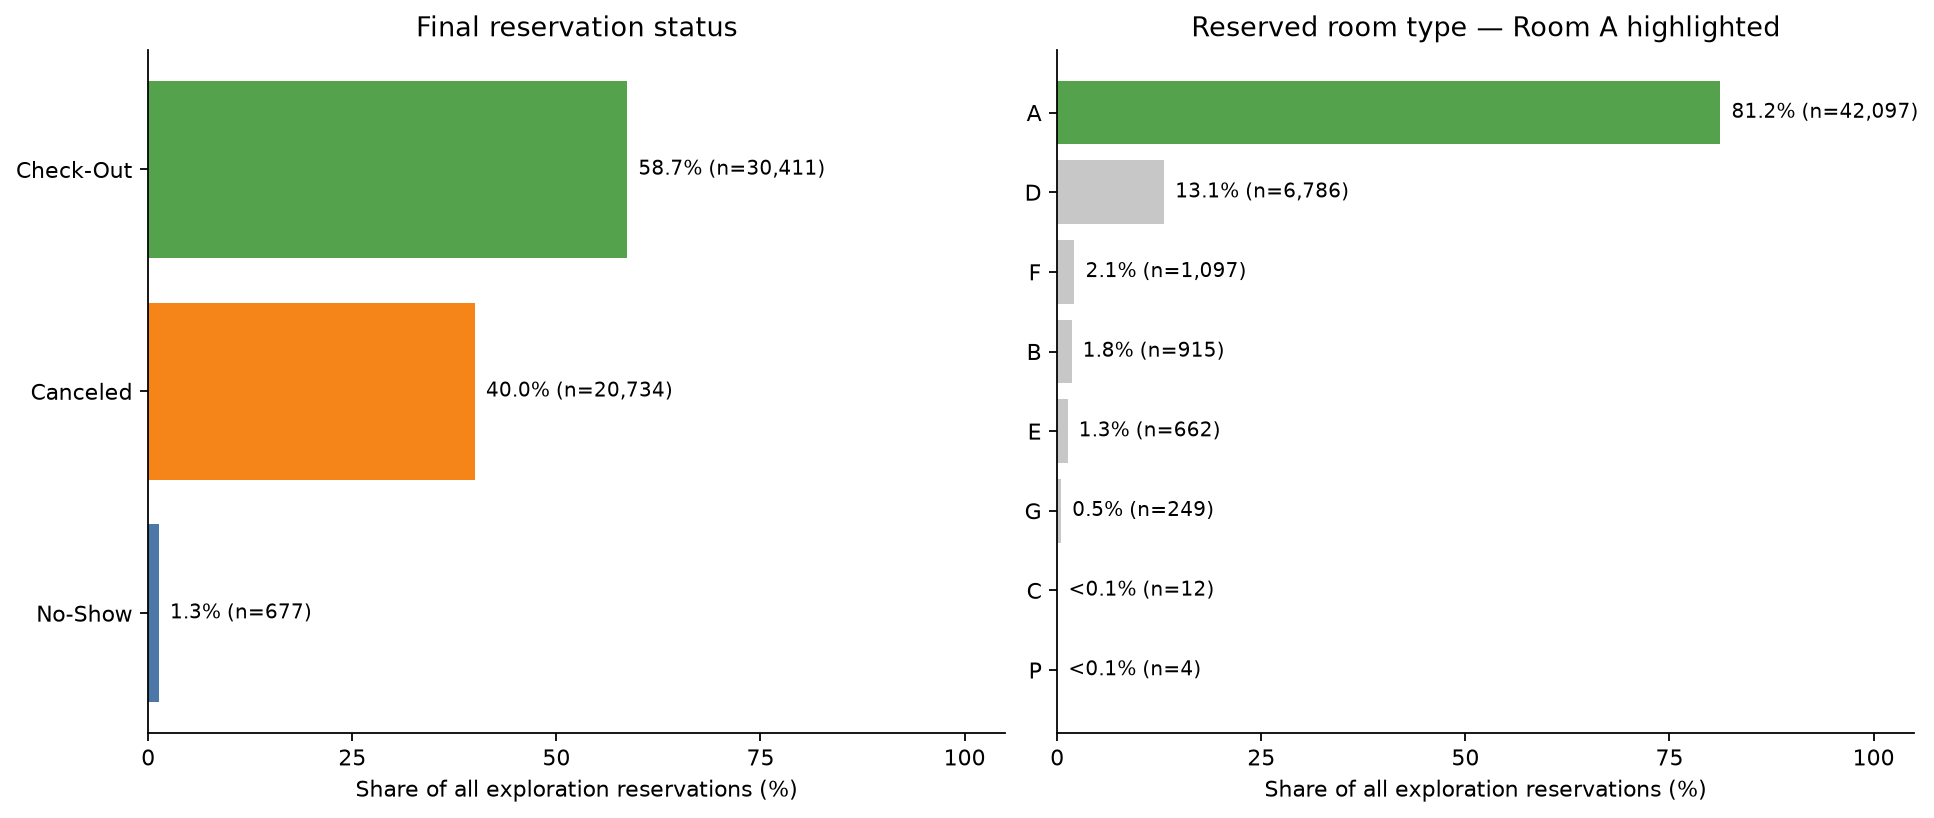

In [2]:
show_plot('outputs/analysis/status_and_room_share.png')

Room A accounts for **81.2%** of the earlier reservations. It gives a large group for a one-room-type scenario.

- Completed room-A stays with positive nights and ADR have median ADR **90.95** across 23,210 records. I round it to **90** for the reference price.
- Across all earlier room-A reservations, p90 lead time is **301 days**. Including arrival day and rounding up gives **330 daily decisions**, covering 93.6% of recorded lead times.

These choices describe bookings, not optimal prices or shopper demand. Removing identical rows changes room-A p90 to 183 days; I retain them because separate anonymized reservations may look alike. The reserved 2017 data remains unused.

## 2. Define the simulated hotel

I model 10 rooms for one arrival date and one stay night, with up to 330 daily decisions. Inventory does not reset each day.

- **State:** time and rooms remaining.
- **Action:** offer 55, 70, 90, 110, or 125.
- **Reward:** actual sales revenue that day.
- **Ending:** sellout or the last day; unsold rooms have no value.

At most one room sells per day. There are no cancellations or seasonal changes. The price menu is chosen around 90, and the assumed sale probability at 90 is `12 / 330`.

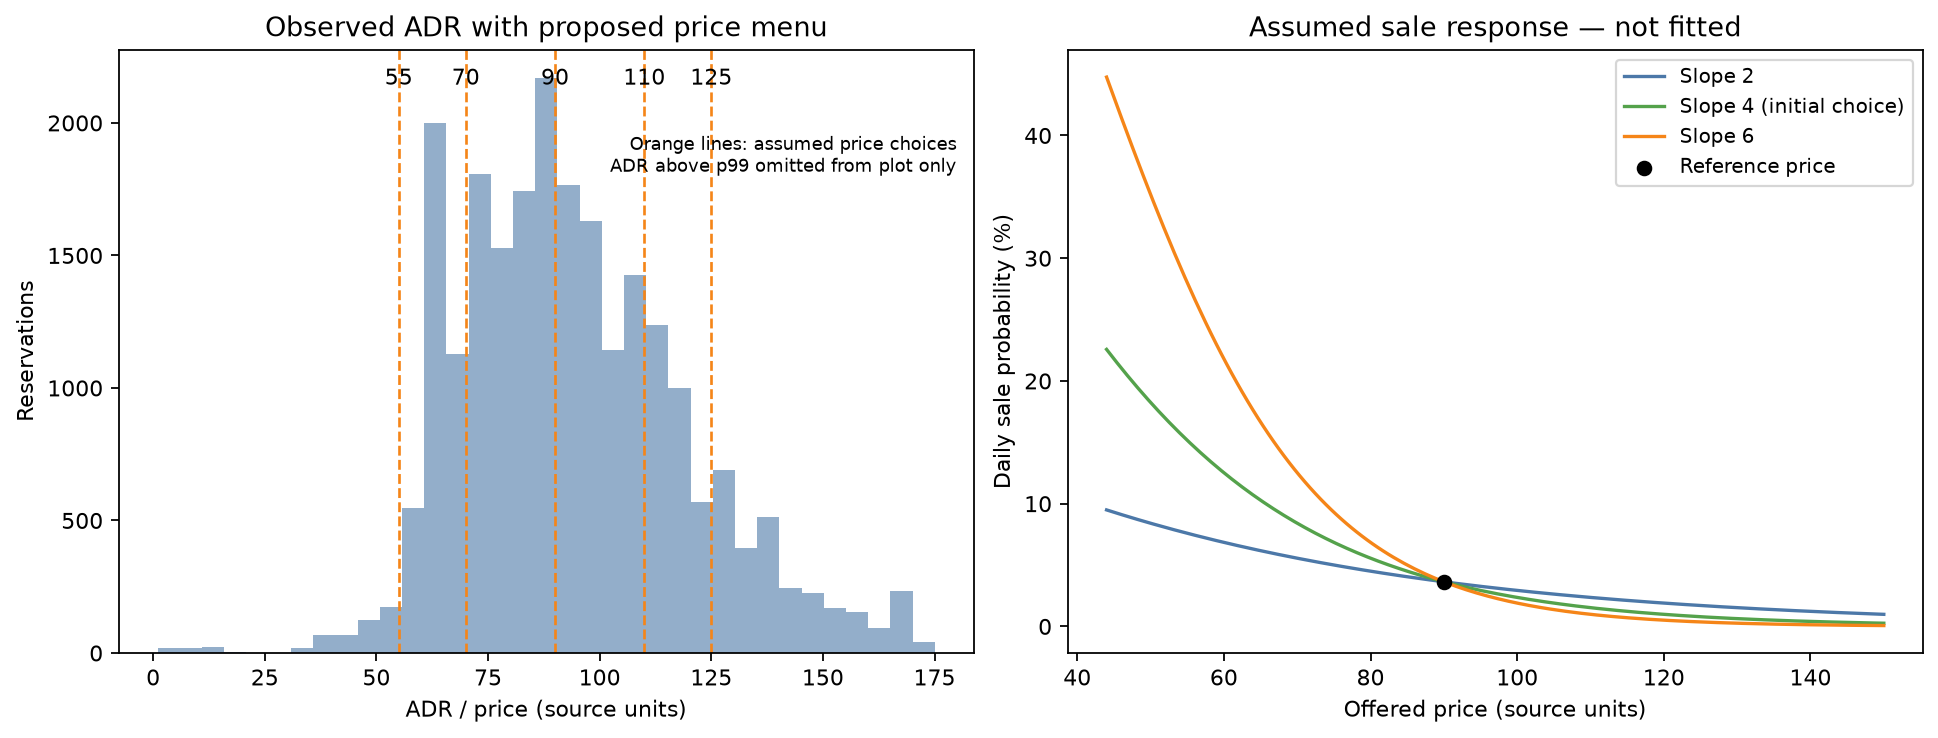

In [3]:
show_plot('outputs/analysis/simulator_parameters.png')

The left plot places the price menu on recorded ADR. The right shows assumed sale probabilities: slope 4 is used, while 2 and 6 are illustrations.

The bookings inform the price scale and window. They do not identify the response to price or available inventory. Omitting cancellations is substantial: 40.0% of the earlier reservations were canceled and 1.3% were no-shows.

## 3. Follow a decision

Gymnasium's `reset()` starts a selling window, or **episode**. `step(action)` runs one day. A **policy** chooses the action.

From `[330, 10]`, action 2 offers 90. A sale gives reward 90 and state `[329, 9]`; no sale gives reward 0 and `[329, 10]`. I run one repeatable example.

In [4]:
env = HotelPricingEnv(config)
state, _ = env.reset(seed=7)
action = 2  # Offer 90.
next_state, reward, terminated, truncated, info = env.step(action)
env.close()

print('State before:', state.tolist())
print('Offered price:', info['price'])
print('Revenue today:', reward)
print('State after:', next_state.tolist())
print('Episode ended:', terminated)

State before: [330, 10]
Offered price: 90
Revenue today: 0.0
State after: [329, 10]
Episode ended: False


The ending flag marks sellout or the last day. An outside interruption would set `truncated`, which stays False here.

A complete episode repeats the same step. I plot the first saved training episode to see how price, sales, and inventory change together.

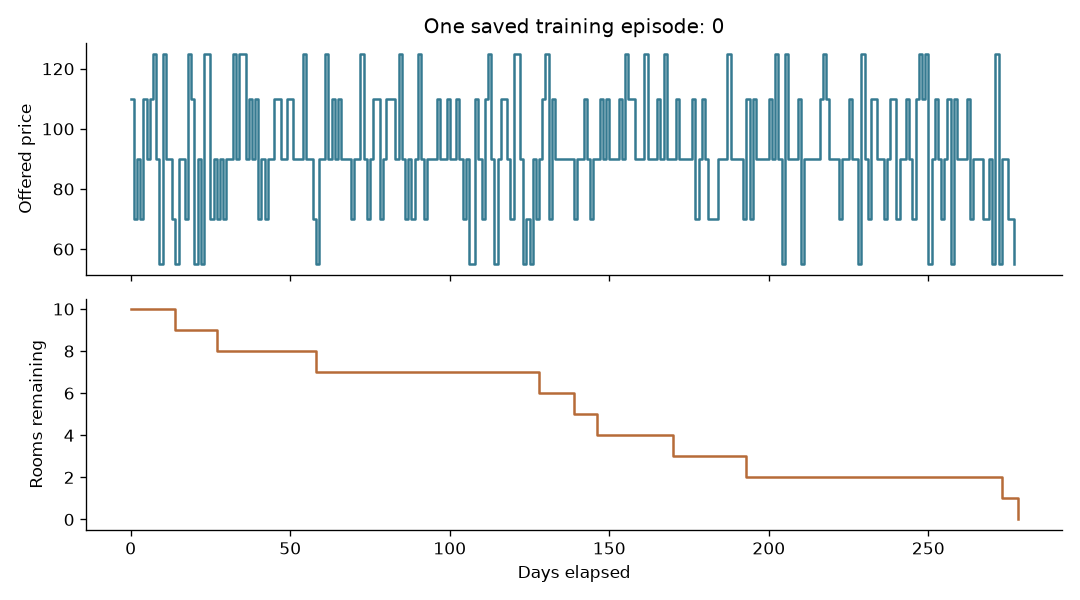

In [5]:
show_plot('outputs/simulator/saved_episode.png')

Prices change because the collection policy samples them randomly. Inventory falls only after a sale, while time passes every day. No-sale days are therefore part of the experience too.

## 4. Collect and freeze the data

The behavior policy chooses the five prices with probabilities **10%, 15%, 50%, 15%, and 10%**. It does not learn.

I collect 2,000 episodes and split whole episodes 80%/10%/10% into training, validation, and test sets. Training changes the weights; validation checks fitting; test transitions are inspected after final models are fixed. No settings or checkpoints are selected from these checks.

Each row records state, action, reward, next state, and ending flag. The files also record seeds, action probabilities, and checksums.

In [6]:
for name in ['train', 'validation', 'test']:
    saved = dataset['files'][name]
    print(f"{name}: {saved['episodes']:,} episodes, {saved['transitions']:,} daily decisions")

training = dataset['files']['train']
display(Markdown(
    f"- **No-sale days:** {training['no_sale_fraction']:.1%} of training decisions.\n"
    f"- **State–price coverage:** {training['state_action_coverage']:.1%} of reachable combinations "
    "appear at least once."
))

train: 1,600 episodes, 324,260 daily decisions
validation: 200 episodes, 40,688 daily decisions
test: 200 episodes, 40,110 daily decisions


- **No-sale days:** 95.1% of training decisions.
- **State–price coverage:** 73.0% of reachable combinations appear at least once.

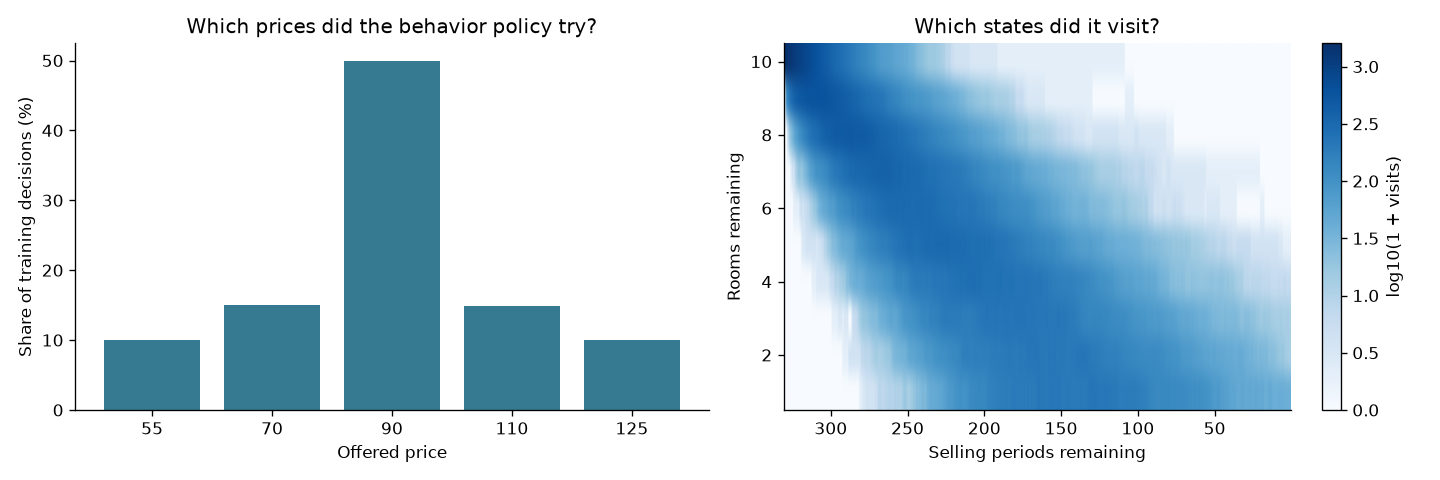

In [7]:
show_plot('outputs/simulator/training_coverage.png')

All five prices appear, but some states are rare or absent. The right plot uses a logarithmic scale to show visits; one visit counts as covered, not as reliable knowledge.

This fixed experience limits what an offline learner can learn. The split is separate from the year-based split of real bookings.

## 5. Learn action values

The model predicts five **Q-values**: estimated total future revenue from choosing each price now and following the learned rule afterward. It cannot try new prices during training.

For a recorded transition:

`target = today's reward + best predicted value at the next state`

At the episode's end, future value is zero. `gamma = 1` gives later revenue equal weight. Rewards are divided by 90 for fitting; evaluation uses original units. Here is the implemented target calculation.

In [8]:
display(Code(inspect.getsource(bellman_target), language='python'))

def bellman_target(rewards, terminated, next_q):
    # Gamma=1: total finite-horizon revenue; no future value after termination.
    best_future_value = next_q.max(dim=1).values
    episode_continues = (~terminated).float()
    return rewards + episode_continues * best_future_value

A periodically copied **target network** supplies the future predictions. The model reduces the difference between its recorded-action value and the target.

**Add caution with CQL**

Unsupported actions can receive high values. CQL penalizes high action values relative to recorded actions:

`loss = prediction error + alpha × CQL penalty`

Below, `gather` selects recorded-action values; `logsumexp` combines all values with more weight on larger ones.

In [9]:
display(Code(inspect.getsource(conservative_penalty), language='python'))

def conservative_penalty(q, actions):
    # gather selects the value of the price actually recorded in each row.
    recorded_action_values = q.gather(1, actions[:, None]).squeeze(1)
    # logsumexp combines all price values, giving more weight to high ones.
    all_action_values = torch.logsumexp(q, dim=1)
    return (all_action_values - recorded_action_values).mean()

The penalty encourages caution about unsupported actions. It cannot fill gaps in the data or guarantee a better policy. This is a discrete implementation of [Conservative Q-Learning](https://arxiv.org/abs/2006.04779).

## 6. Check training

The network has two scaled inputs, two hidden layers of 64 units, and five outputs. Each update samples saved transitions and adjusts its weights.

- 20,000 updates per seed, with batches of 256 transitions.
- Seeds 0, 1, and 2 on the same dataset.
- Adam learning rate 0.0003, CQL weight 0.1.
- Target network refreshed every 100 updates.

I retain every final checkpoint. These runs vary training randomness; they are not independent data replications. The plots show validation prediction error and the training penalty.

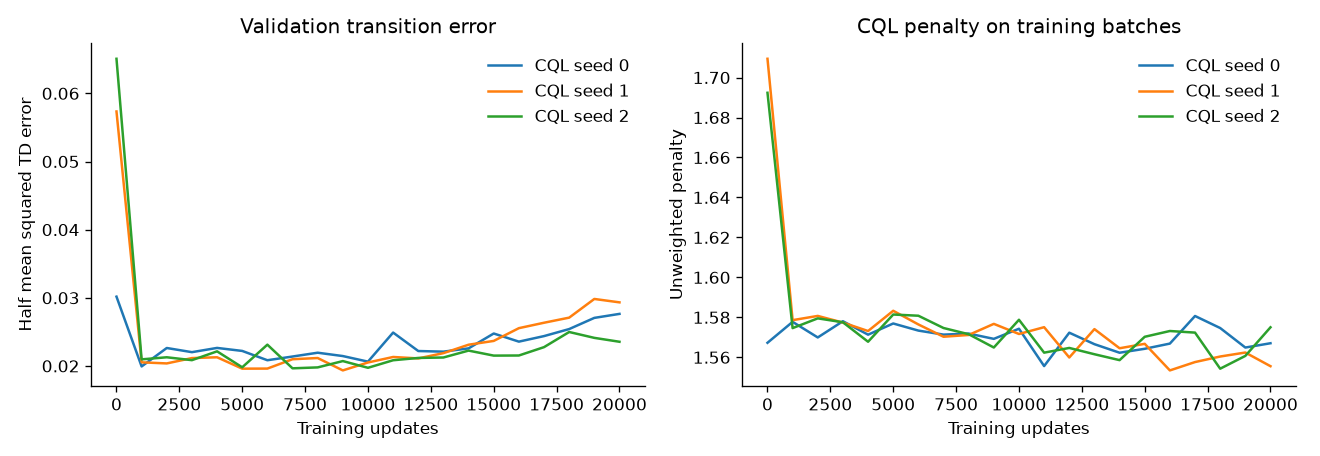

In [10]:
show_plot('outputs/cql/training_curves.png')

Prediction error drops early, then levels off. These curves describe fitting rather than revenue, so they cannot establish that the learned pricing rule is good.

## 7. Evaluate revenue

Each frozen policy runs on 1,000 fresh episodes with matched sale random numbers. I compare CQL with the collection policy, fixed price 90, the best fixed price, and the dynamic optimum.

The best fixed price and optimum use known sale probabilities. They are model-informed benchmarks, not policies that know future random outcomes.

Bars show simulated means with approximate 95% intervals. Dots show exact expected revenue under the assumed model.

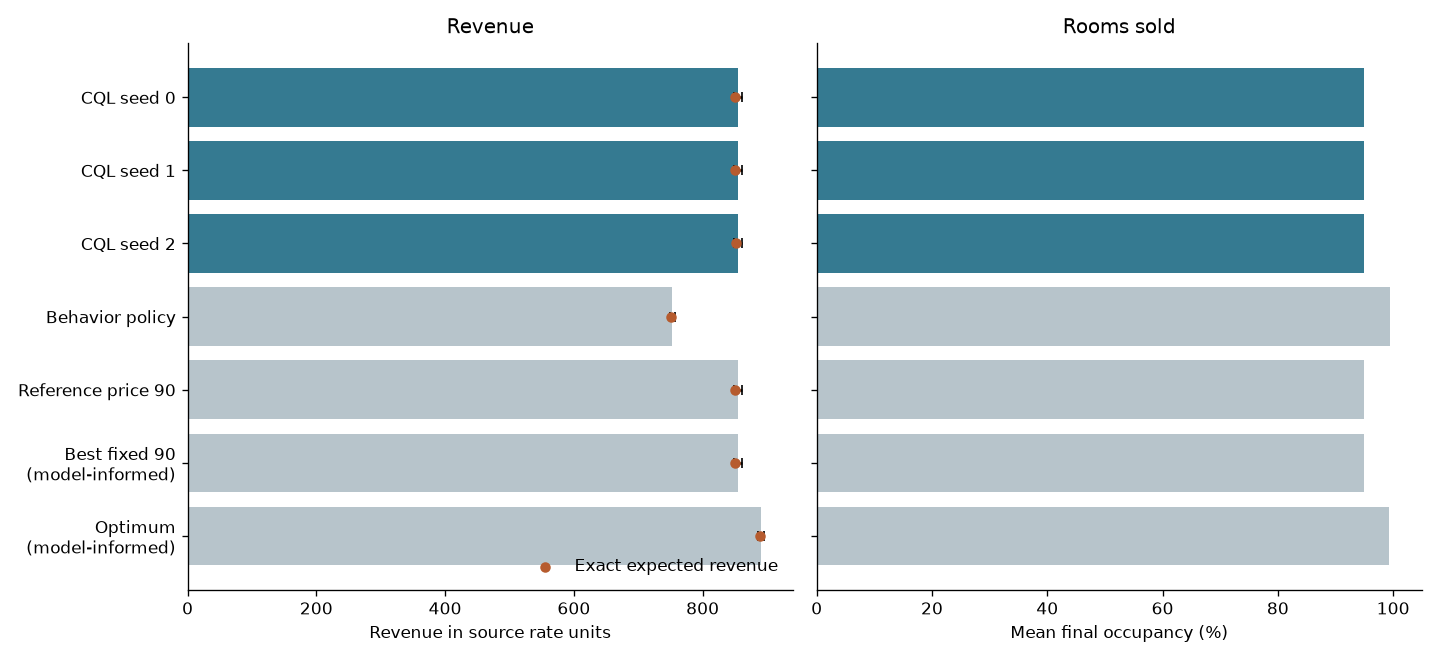

In [11]:
show_plot('outputs/cql/policy_comparison.png')

In [12]:
results = {row['policy']: row for row in run['results']}
cql_rows = [row for row in run['results'] if row['policy'].startswith('CQL')]
cql_values = [row['exact_revenue'] for row in cql_rows]
fixed_name = next(name for name in results if name.startswith('Best fixed'))
optimum = results['Optimum (model-informed)']['exact_revenue']

display(Markdown(
    f"- **Behavior policy:** {results['Behavior policy']['exact_revenue']:.2f} expected revenue.\n"
    f"- **CQL across three seeds:** {min(cql_values):.2f}–{max(cql_values):.2f}.\n"
    f"- **{fixed_name}:** {results[fixed_name]['exact_revenue']:.2f}.\n"
    f"- **Model-informed optimum:** {optimum:.2f}."
))

- **Behavior policy:** 750.33 expected revenue.
- **CQL across three seeds:** 851.00–851.08.
- **Best fixed 90 (model-informed):** 851.00.
- **Model-informed optimum:** 888.41.

CQL earns about **851**, improving on the random mix but barely changing the best fixed-price result. The model-informed optimum is about **888**, leaving a gap of roughly **4.2%**.

Seeds 0 and 1 both always charge 90. Seed 2 gains only **0.08** in exact expected revenue, or **0.0093%**. This is too small to claim a meaningful practical improvement. Price 90 being best depends on the chosen demand curve, capacity, and price menu.

The exact difference has no rollout sampling noise, but depends on the assumed model. The plotted intervals are not a test of the difference. Only one of the 1,000 paired episodes differs between seed 2 and fixed price 90.

## 8. Inspect the decisions

Each map gives the price at a time-and-inventory state. Time runs from 330 on the left to 1 on the right; lower rows have fewer rooms. Blank states are unreachable. A predicted price alone does not establish that the state had enough training data.

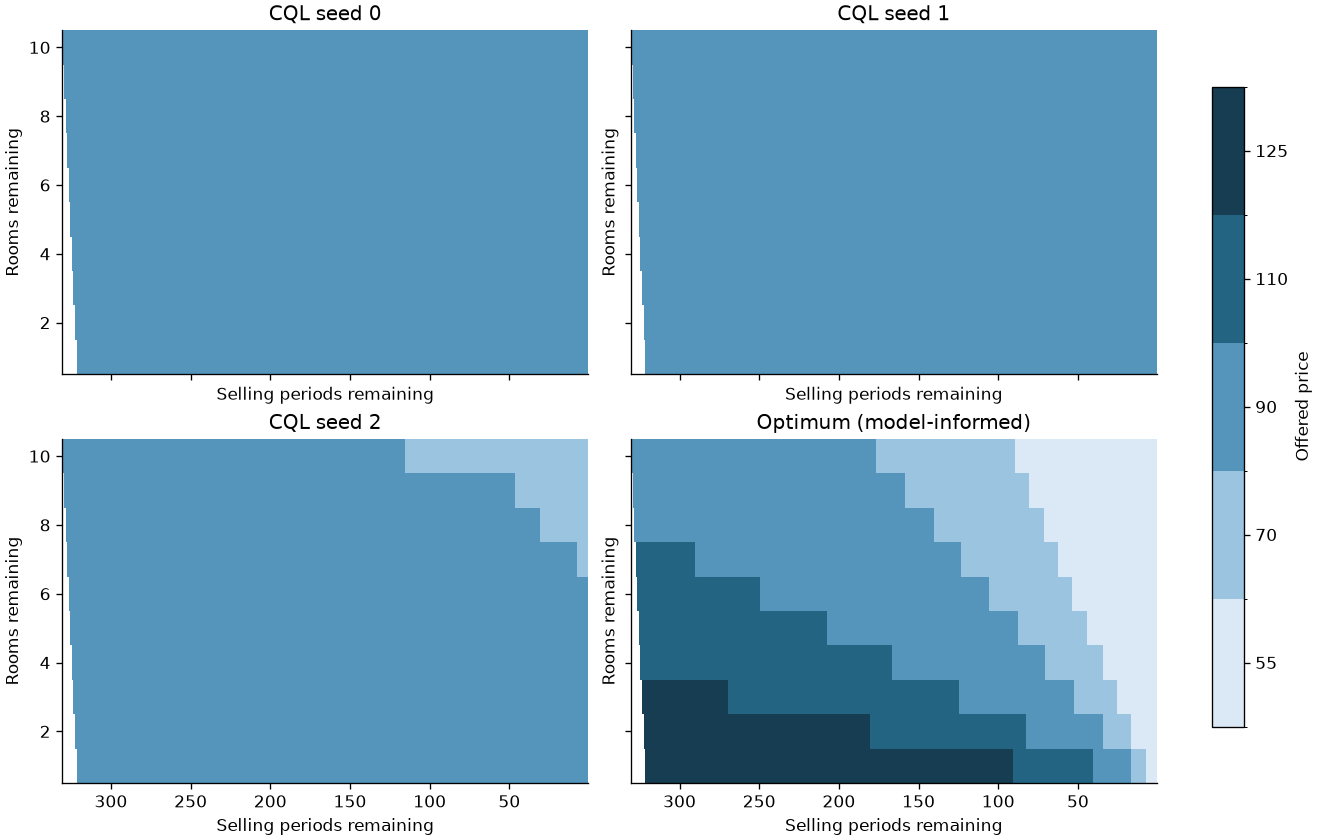

In [13]:
show_plot('outputs/cql/policy_maps.png')

Seeds 0 and 1 always choose 90. Seed 2 sometimes reduces the price when many rooms remain. For example, with 50 periods left, it charges 70 for 10 rooms and 90 for 2 rooms.

The optimum responds more strongly: with 200 periods left, it charges 90 for 10 rooms and 125 for 2. With 10 rooms and only 50 periods left, it charges 55.

CQL has not recovered most of this dynamic pattern. Coverage, the penalty, network fitting, and training budget are possible explanations, not established causes.

## 9. Conclusion

The full process works: a simulator produces fixed experience, CQL learns from it, and separate evaluation measures the learned policy. The first model mainly recovers a good fixed price.

This establishes a working experiment, not a real-hotel revenue gain. The customer price response is assumed, cancellations and longer stays are omitted, and training choices have not been tuned. Further comparisons should change one factor at a time and use fresh final evaluation episodes.

**Supporting notebooks**

- [Booking patterns](01_hotel_booking_patterns.ipynb)
- [Simulator and saved data](02_simulator_and_offline_data.ipynb)
- [CQL training and evaluation](03_offline_cql.ipynb)

The figures and results come from the saved v1 experiment. Source excerpts use the frozen v1 implementation.